# NB-06: 有効性検証

実測めぐ指数（NB-04）・想定めぐ指数（NB-05）の予測有効性を検証する。

## 検証項目
1. **実測めぐ指数の有効性**: レース内スピアマン相関、デシル別勝率・複勝率
2. **想定めぐ指数の有効性**: パターンA/B/C の予測力検証（学習期間・テスト期間）
3. **指数1位の命中率**: 各レースで最高指数馬が1着/3着以内になる率と年別推移
4. **サマリーレポート**: effectiveness_report.md 出力

## 処理フロー
1. セットアップ・データロード
2. 実測めぐ指数の有効性
3. 想定めぐ指数の有効性
4. 指数1位の命中率
5. サマリーレポート出力
6. 保存

## セクション1: セットアップ・データロード

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ---- 入出力パス定義 ----
NB04_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb04')
NB05_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb05')
OUTPUT_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb06')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 学習期間 / テスト期間の境界
TRAIN_END = '2024-12-31'
TEST_START = '2025-01-01'

print('パス設定完了')

パス設定完了


In [2]:
# ---- データ読み込み ----
print('データ読み込み中...')

megu_index = pd.read_parquet(NB04_DIR / 'megu_index.parquet')
print(f'  megu_index: {len(megu_index):,} 行')

megu_final = pd.read_parquet(NB05_DIR / 'megu_final.parquet')
print(f'  megu_final: {len(megu_final):,} 行')

# マージ（race_id × horse_id）
df = megu_index.merge(
    megu_final[['race_id', 'horse_id', 'megu_a', 'megu_b', 'megu_c', 'n_valid_runs']],
    on=['race_id', 'horse_id'],
    how='left'
)
print(f'  マージ後: {len(df):,} 行')

# date を datetime に変換
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# 学習/テスト フラグ
df['split'] = np.where(df['date'] <= TRAIN_END, 'train', 'test')
print(f'  train: {(df["split"]=="train").sum():,} 行')
print(f'  test:  {(df["split"]=="test").sum():,} 行')

print('データ読み込み完了')

データ読み込み中...
  megu_index: 302,357 行
  megu_final: 302,357 行
  マージ後: 302,357 行
  train: 234,570 行
  test:  67,787 行
データ読み込み完了


## セクション2: 実測めぐ指数の有効性

In [3]:
# ---- 2-1: レース内スピアマン相関（megu_index vs finish_pos） ----
print('=== レース内スピアマン相関（実測めぐ指数 vs 着順）===')
print('期待: 負相関 → 指数が高いほど着順が良い（小さい）')

def compute_race_spearman(data: pd.DataFrame, x_col: str, y_col: str = 'finish_pos') -> pd.Series:
    """各レース内でスピアマン相関を計算し、Series で返す。"""
    def spearman_race(group):
        g = group[[x_col, y_col]].dropna()
        if len(g) < 3:
            return np.nan
        rho, _ = stats.spearmanr(g[x_col], g[y_col])
        return rho
    return data.groupby('race_id').apply(spearman_race)

# 全体
spearman_all = compute_race_spearman(
    df[df['megu_index'].notna()], 'megu_index'
)
print(f'\n全体:')
print(f'  平均: {spearman_all.mean():.4f}')
print(f'  中央値: {spearman_all.median():.4f}')
print(f'  std: {spearman_all.std():.4f}')
print(f'  負相関率: {(spearman_all < 0).mean():.1%}')

=== レース内スピアマン相関（実測めぐ指数 vs 着順）===
期待: 負相関 → 指数が高いほど着順が良い（小さい）

全体:
  平均: -0.9533
  中央値: -0.9791
  std: 0.0716
  負相関率: 99.8%


In [4]:
# ---- 2-2: 芝/ダート別・クラス別・距離帯別のスピアマン相関 ----
print('=== 芝/ダート別・クラス別スピアマン相関 ===')

results_spearman = {'全体': (spearman_all.mean(), spearman_all.median(), len(spearman_all))}

# 芝/ダート別
for surf in ['芝', 'ダ']:
    subset = df[(df['surface'] == surf) & df['megu_index'].notna()]
    if len(subset) > 0:
        rho_series = compute_race_spearman(subset, 'megu_index')
        results_spearman[f'surface={surf}'] = (rho_series.mean(), rho_series.median(), len(rho_series))
        print(f'  {surf}: 平均={rho_series.mean():.4f}, 中央値={rho_series.median():.4f}, N={len(rho_series):,}')

# クラス別
print('\nクラス別:')
for cr in sorted(df['class_rank'].unique()):
    subset = df[(df['class_rank'] == cr) & df['megu_index'].notna()]
    if len(subset) > 0:
        rho_series = compute_race_spearman(subset, 'megu_index')
        results_spearman[f'class_rank={cr}'] = (rho_series.mean(), rho_series.median(), len(rho_series))
        print(f'  class_rank={cr}: 平均={rho_series.mean():.4f}, 中央値={rho_series.median():.4f}, N={len(rho_series):,}')

=== 芝/ダート別・クラス別スピアマン相関 ===
  芝: 平均=-0.9376, 中央値=-0.9643, N=11,103

クラス別:
  class_rank=1: 平均=-0.9621, 中央値=-0.9818, N=8,722
  class_rank=5: 平均=-0.9476, 中央値=-0.9778, N=13,312


In [5]:
# ---- 2-3: 距離帯別スピアマン相関 ----
print('=== 距離帯別スピアマン相関 ===')

def get_distance_band(dist):
    if dist <= 1400:
        return 'sprint'
    elif dist <= 1800:
        return 'mile'
    elif dist <= 2200:
        return 'intermediate'
    else:
        return 'long'

if 'distance_band' not in df.columns:
    df['distance_band'] = df['distance'].apply(get_distance_band)

for db in ['sprint', 'mile', 'intermediate', 'long']:
    subset = df[(df['distance_band'] == db) & df['megu_index'].notna()]
    if len(subset) > 0:
        rho_series = compute_race_spearman(subset, 'megu_index')
        results_spearman[f'dist_band={db}'] = (rho_series.mean(), rho_series.median(), len(rho_series))
        print(f'  {db}: 平均={rho_series.mean():.4f}, 中央値={rho_series.median():.4f}, N={len(rho_series):,}')

=== 距離帯別スピアマン相関 ===
  sprint: 平均=-0.9627, 中央値=-0.9818, N=7,885
  mile: 平均=-0.9519, 中央値=-0.9766, N=9,207
  intermediate: 平均=-0.9349, 中央値=-0.9710, N=3,368
  long: 平均=-0.9542, 中央値=-0.9910, N=1,574


=== デシル別勝率・複勝率（実測めぐ指数）===
             win_rate  place_rate  count
megu_decile                             
0.0            0.0002      0.0057  37148
1.0            0.0002      0.0040  24642
2.0            0.0008      0.0098  22517
3.0            0.0024      0.0367  24712
4.0            0.0051      0.0644  26297
5.0            0.0137      0.1552  20691
6.0            0.0298      0.2759  22084
7.0            0.0908      0.5690  23880
8.0            0.2380      0.8829  20270
9.0            0.6074      0.9688  22902


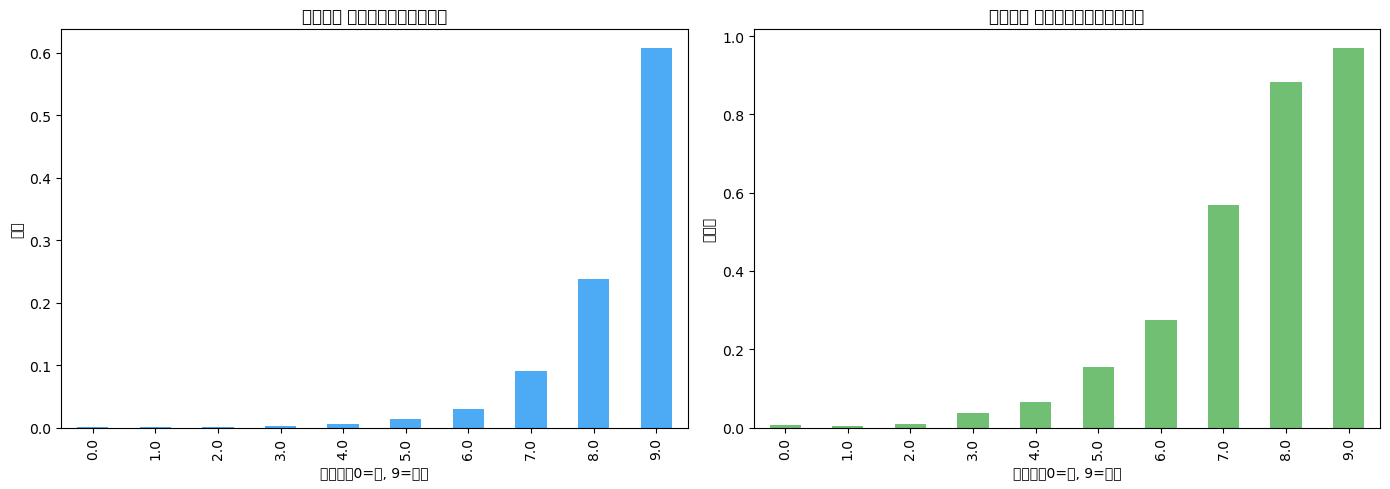

デシル別勝率プロット 保存完了


In [6]:
# ---- 2-4: デシル別勝率・複勝率 ----
print('=== デシル別勝率・複勝率（実測めぐ指数）===')

df_valid_megu = df[df['megu_index'].notna()].copy()

# レース内での megu_index の分位（10分位）
df_valid_megu['megu_decile'] = df_valid_megu.groupby('race_id')['megu_index'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)

df_valid_megu['win'] = (df_valid_megu['finish_pos'] == 1).astype(int)
df_valid_megu['place'] = (df_valid_megu['finish_pos'] <= 3).astype(int)

decile_stats = (
    df_valid_megu.groupby('megu_decile')
    .agg(
        win_rate=('win', 'mean'),
        place_rate=('place', 'mean'),
        count=('win', 'count')
    )
    .round(4)
)
print(decile_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
decile_stats['win_rate'].plot(kind='bar', ax=axes[0], color='#2196F3', alpha=0.8)
axes[0].set_title('デシル別 勝率（実測めぐ指数）')
axes[0].set_xlabel('デシル（0=低, 9=高）')
axes[0].set_ylabel('勝率')

decile_stats['place_rate'].plot(kind='bar', ax=axes[1], color='#4CAF50', alpha=0.8)
axes[1].set_title('デシル別 複勝率（実測めぐ指数）')
axes[1].set_xlabel('デシル（0=低, 9=高）')
axes[1].set_ylabel('複勝率')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'megu_index_decile_rates.png', dpi=100)
plt.show()
print('デシル別勝率プロット 保存完了')

## セクション3: 想定めぐ指数の有効性

In [7]:
# ---- 3-1: パターンA/B/C のスピアマン相関（全体・train/test別）----
print('=== 想定めぐ指数 スピアマン相関（全体・train/test別）===')

pattern_results = {}

for col in ['megu_a', 'megu_b', 'megu_c']:
    pattern_results[col] = {}
    for split_label in ['全体', 'train', 'test']:
        if split_label == '全体':
            subset = df[df[col].notna()]
        else:
            subset = df[(df['split'] == split_label) & df[col].notna()]

        if len(subset) == 0:
            continue

        rho_series = compute_race_spearman(subset, col)
        rho_mean = rho_series.mean()
        rho_median = rho_series.median()
        pattern_results[col][split_label] = {
            'mean': rho_mean,
            'median': rho_median,
            'n_races': len(rho_series)
        }
        print(f'  {col} [{split_label}]: 平均={rho_mean:.4f}, 中央値={rho_median:.4f}, N={len(rho_series):,}')

=== 想定めぐ指数 スピアマン相関（全体・train/test別）===
  megu_a [全体]: 平均=-0.2435, 中央値=-0.2606, N=20,023
  megu_a [train]: 平均=-0.2444, 中央値=-0.2607, N=15,495
  megu_a [test]: 平均=-0.2402, 中央値=-0.2575, N=4,528
  megu_b [全体]: 平均=-0.2521, 中央値=-0.2692, N=20,023
  megu_b [train]: 平均=-0.2554, 中央値=-0.2727, N=15,495
  megu_b [test]: 平均=-0.2409, 中央値=-0.2559, N=4,528
  megu_c [全体]: 平均=-0.2356, 中央値=-0.2587, N=19,889
  megu_c [train]: 平均=-0.2371, 中央値=-0.2587, N=15,385
  megu_c [test]: 平均=-0.2306, 中央値=-0.2587, N=4,504


=== 想定めぐ指数 デシル別勝率・複勝率 ===

megu_a:
        win_rate  place_rate
decile                      
0.0       0.0315      0.1164
1.0       0.0430      0.1502
2.0       0.0528      0.1781
3.0       0.0598      0.1977
4.0       0.0687      0.2221
5.0       0.0767      0.2349
6.0       0.0923      0.2665
7.0       0.1021      0.2927
8.0       0.1129      0.3296
9.0       0.1378      0.3525

megu_b:
        win_rate  place_rate
decile                      
0.0       0.0302      0.1097
1.0       0.0428      0.1532
2.0       0.0470      0.1713
3.0       0.0554      0.1891
4.0       0.0667      0.2196
5.0       0.0762      0.2337
6.0       0.0881      0.2627
7.0       0.1039      0.2973
8.0       0.1189      0.3320
9.0       0.1455      0.3675

megu_c:
        win_rate  place_rate
decile                      
0.0       0.0406      0.1424
1.0       0.0495      0.1703
2.0       0.0521      0.1849
3.0       0.0650      0.2169
4.0       0.0757      0.2416
5.0       0.0808      0.2555
6.0       0.0915   

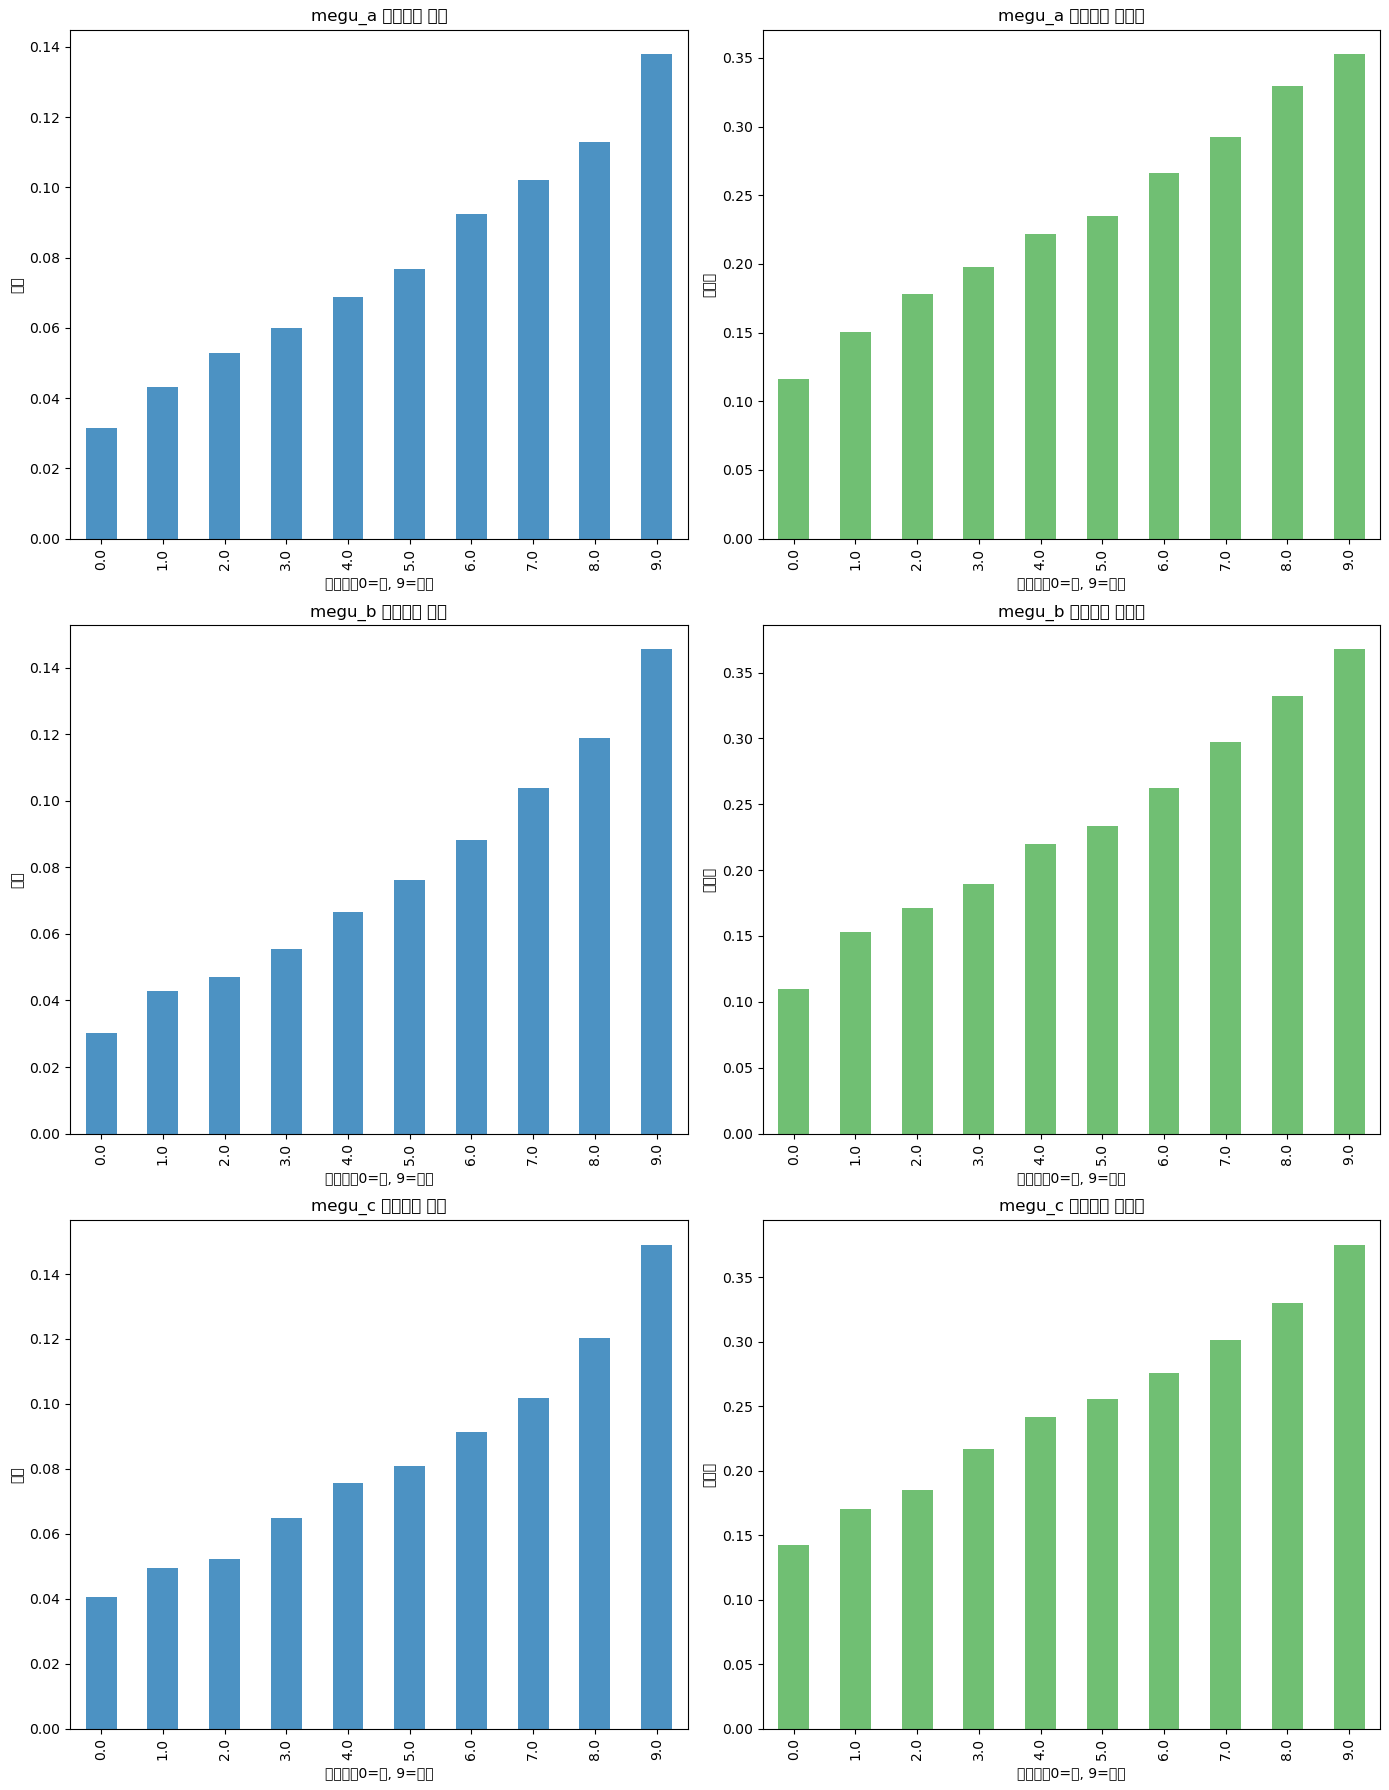

デシル別勝率プロット 保存完了


In [8]:
# ---- 3-2: パターンA/B/C のデシル別勝率・複勝率 ----
print('=== 想定めぐ指数 デシル別勝率・複勝率 ===')

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

decile_results = {}

for idx, col in enumerate(['megu_a', 'megu_b', 'megu_c']):
    df_subset = df[df[col].notna()].copy()
    df_subset['decile'] = df_subset.groupby('race_id')[col].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    df_subset['win'] = (df_subset['finish_pos'] == 1).astype(int)
    df_subset['place'] = (df_subset['finish_pos'] <= 3).astype(int)

    stats_df = (
        df_subset.groupby('decile')
        .agg(win_rate=('win', 'mean'), place_rate=('place', 'mean'))
        .round(4)
    )
    decile_results[col] = stats_df

    stats_df['win_rate'].plot(kind='bar', ax=axes[idx][0], alpha=0.8)
    axes[idx][0].set_title(f'{col} デシル別 勝率')
    axes[idx][0].set_xlabel('デシル（0=低, 9=高）')
    axes[idx][0].set_ylabel('勝率')

    stats_df['place_rate'].plot(kind='bar', ax=axes[idx][1], alpha=0.8, color='#4CAF50')
    axes[idx][1].set_title(f'{col} デシル別 複勝率')
    axes[idx][1].set_xlabel('デシル（0=低, 9=高）')
    axes[idx][1].set_ylabel('複勝率')

    print(f'\n{col}:')
    print(stats_df)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'megu_final_decile_rates.png', dpi=100)
plt.show()
print('デシル別勝率プロット 保存完了')

## セクション4: 指数1位の命中率

In [9]:
# ---- 4-1: 各レースで想定めぐ指数B最高の馬が実際に1着/3着以内になる率 ----
print('=== 指数1位命中率（megu_b ベース）===')

def compute_top1_accuracy(data: pd.DataFrame, score_col: str) -> dict:
    """各レースで score_col 最高の馬の1着/3着以内命中率を計算。"""
    df_sub = data[data[score_col].notna()].copy()

    # 各レースのスコア最高の馬を取得
    idx_max = df_sub.groupby('race_id')[score_col].idxmax()
    top1 = df_sub.loc[idx_max, ['race_id', 'horse_id', 'finish_pos']]

    win_rate = (top1['finish_pos'] == 1).mean()
    place_rate = (top1['finish_pos'] <= 3).mean()
    n_races = len(top1)

    return {'win_rate': win_rate, 'place_rate': place_rate, 'n_races': n_races, 'top1': top1}

for col in ['megu_a', 'megu_b', 'megu_c']:
    result = compute_top1_accuracy(df, col)
    print(f'\n{col} 指数1位:')
    print(f'  勝率: {result["win_rate"]:.1%}')
    print(f'  複勝率: {result["place_rate"]:.1%}')
    print(f'  対象レース数: {result["n_races"]:,}')

=== 指数1位命中率（megu_b ベース）===

megu_a 指数1位:
  勝率: 15.3%
  複勝率: 38.3%
  対象レース数: 20,023

megu_b 指数1位:
  勝率: 16.4%
  複勝率: 39.4%
  対象レース数: 20,023

megu_c 指数1位:
  勝率: 16.6%
  複勝率: 41.1%
  対象レース数: 19,889


=== 指数1位命中率の年別推移（megu_b）===
 year  win_rate  place_rate  n_races
 2020  0.146390    0.384024     2992
 2021  0.146279    0.363462     3131
 2022  0.167573    0.410937     3127
 2023  0.167680    0.408960     3125
 2024  0.183333    0.418590     3120
 2025  0.179233    0.394569     3130
 2026  0.145923    0.360515     1398


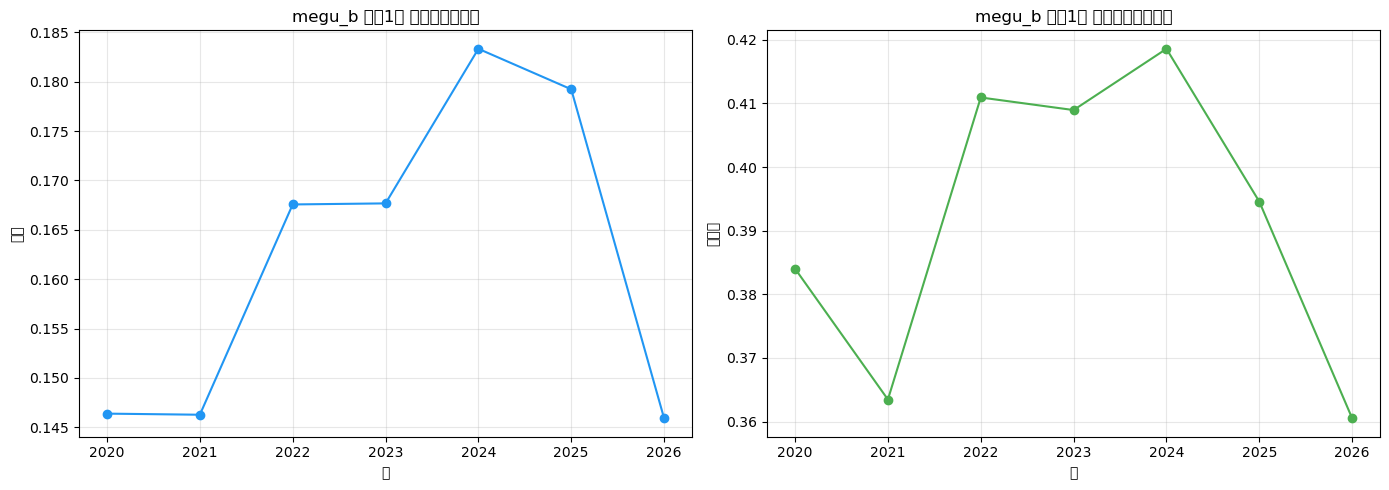

年別推移プロット 保存完了


In [10]:
# ---- 4-2: 年別推移（経時安定性）----
print('=== 指数1位命中率の年別推移（megu_b）===')

yearly_results = []

for year in sorted(df['year'].unique()):
    df_year = df[df['year'] == year]
    result = compute_top1_accuracy(df_year, 'megu_b')
    yearly_results.append({
        'year': year,
        'win_rate': result['win_rate'],
        'place_rate': result['place_rate'],
        'n_races': result['n_races']
    })

yearly_df = pd.DataFrame(yearly_results)
print(yearly_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly_df['year'], yearly_df['win_rate'], marker='o', color='#2196F3')
axes[0].set_title('megu_b 指数1位 勝率の年別推移')
axes[0].set_xlabel('年')
axes[0].set_ylabel('勝率')
axes[0].grid(True, alpha=0.3)

axes[1].plot(yearly_df['year'], yearly_df['place_rate'], marker='o', color='#4CAF50')
axes[1].set_title('megu_b 指数1位 複勝率の年別推移')
axes[1].set_xlabel('年')
axes[1].set_ylabel('複勝率')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top1_accuracy_by_year.png', dpi=100)
plt.show()
print('年別推移プロット 保存完了')

## セクション5: サマリーレポート出力

In [11]:
# ---- サマリーデータの集計 ----
print('サマリーデータ集計中...')

# 実測めぐ指数のスピアマン相関（全体）
spearman_mean_actual = spearman_all.mean()
spearman_median_actual = spearman_all.median()

# 想定めぐ指数B の全体スピアマン
spearman_b_train = pattern_results.get('megu_b', {}).get('train', {}).get('mean', np.nan)
spearman_b_test = pattern_results.get('megu_b', {}).get('test', {}).get('mean', np.nan)

# 指数1位命中率（megu_b）
top1_b = compute_top1_accuracy(df, 'megu_b')
top1_b_win = top1_b['win_rate']
top1_b_place = top1_b['place_rate']

# テスト期間（2025以降）の指数1位命中率
df_test = df[df['split'] == 'test']
if len(df_test) > 0:
    top1_b_test = compute_top1_accuracy(df_test, 'megu_b')
    top1_b_test_win = top1_b_test['win_rate']
    top1_b_test_place = top1_b_test['place_rate']
else:
    top1_b_test_win = np.nan
    top1_b_test_place = np.nan

print('サマリーデータ集計完了')

サマリーデータ集計中...
サマリーデータ集計完了


In [12]:
# ---- effectiveness_report.md 生成 ----
print('effectiveness_report.md 生成中...')

report_lines = [
    '# めぐ指数 有効性検証レポート',
    '',
    f'生成日時: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}',
    '',
    '---',
    '',
    '## 1. 実測めぐ指数の有効性',
    '',
    '### スピアマン相関（megu_index vs finish_pos）',
    '',
    '| 区分 | 平均 | 中央値 | レース数 |',
    '|------|------|--------|---------|',
]

for label, (mean_val, median_val, n) in results_spearman.items():
    report_lines.append(f'| {label} | {mean_val:.4f} | {median_val:.4f} | {n:,} |')

report_lines += [
    '',
    '> 負相関が主 → 指数が高いほど着順が良い（着順数値が小さい）ことを示す。',
    '',
    '---',
    '',
    '## 2. 想定めぐ指数の有効性（パターンA/B/C）',
    '',
    '### スピアマン相関',
    '',
    '| パターン | 期間 | 平均 | 中央値 | レース数 |',
    '|---------|------|------|--------|---------|',
]

for col, splits in pattern_results.items():
    for split_label, vals in splits.items():
        report_lines.append(
            f'| {col} | {split_label} | {vals["mean"]:.4f} | {vals["median"]:.4f} | {vals["n_races"]:,} |'
        )

report_lines += [
    '',
    '---',
    '',
    '## 3. 指数1位の命中率（megu_b）',
    '',
    '### 全体',
    '',
    f'- 勝率: **{top1_b_win:.1%}**',
    f'- 複勝率: **{top1_b_place:.1%}**',
    f'- 対象レース数: {top1_b["n_races"]:,}',
    '',
    '### テスト期間（2025-2026）',
    '',
    f'- 勝率: **{top1_b_test_win:.1%}**' if not np.isnan(top1_b_test_win) else '- 勝率: データなし',
    f'- 複勝率: **{top1_b_test_place:.1%}**' if not np.isnan(top1_b_test_place) else '- 複勝率: データなし',
    '',
    '### 年別推移',
    '',
    '| 年 | 勝率 | 複勝率 | レース数 |',
    '|----|------|--------|---------|',
]

for _, row in yearly_df.iterrows():
    report_lines.append(
        f'| {int(row["year"])} | {row["win_rate"]:.1%} | {row["place_rate"]:.1%} | {int(row["n_races"]):,} |'
    )

report_lines += [
    '',
    '---',
    '',
    '## 4. テスト期間の汎化確認',
    '',
    f'- 学習期間スピアマン平均（megu_b）: {spearman_b_train:.4f}' if not np.isnan(spearman_b_train) else '- 学習期間: データなし',
    f'- テスト期間スピアマン平均（megu_b）: {spearman_b_test:.4f}' if not np.isnan(spearman_b_test) else '- テスト期間: データなし',
    '',
    '> train/test のスピアマン相関が近い値であれば、時系列的な汎化が確認できる。',
    '',
    '---',
    '',
    '*NB-06 自動生成レポート*',
]

report_text = '\n'.join(report_lines)

report_path = OUTPUT_DIR / 'effectiveness_report.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(f'effectiveness_report.md 保存完了: {report_path}')
print('\n--- レポートプレビュー（先頭30行）---')
print('\n'.join(report_lines[:30]))

effectiveness_report.md 生成中...
effectiveness_report.md 保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb06/effectiveness_report.md

--- レポートプレビュー（先頭30行）---
# めぐ指数 有効性検証レポート

生成日時: 2026-07-13 09:42:15

---

## 1. 実測めぐ指数の有効性

### スピアマン相関（megu_index vs finish_pos）

| 区分 | 平均 | 中央値 | レース数 |
|------|------|--------|---------|
| 全体 | -0.9533 | -0.9791 | 22,034 |
| surface=芝 | -0.9376 | -0.9643 | 11,103 |
| class_rank=1 | -0.9621 | -0.9818 | 8,722 |
| class_rank=5 | -0.9476 | -0.9778 | 13,312 |
| dist_band=sprint | -0.9627 | -0.9818 | 7,885 |
| dist_band=mile | -0.9519 | -0.9766 | 9,207 |
| dist_band=intermediate | -0.9349 | -0.9710 | 3,368 |
| dist_band=long | -0.9542 | -0.9910 | 1,574 |

> 負相関が主 → 指数が高いほど着順が良い（着順数値が小さい）ことを示す。

---

## 2. 想定めぐ指数の有効性（パターンA/B/C）

### スピアマン相関

| パターン | 期間 | 平均 | 中央値 | レース数 |


## セクション6: 保存

In [13]:
# ---- 検証結果サマリーを parquet 保存 ----
print('検証結果サマリーを保存中...')

# スピアマン相関サマリー
spearman_summary_rows = []
for label, (mean_val, median_val, n) in results_spearman.items():
    spearman_summary_rows.append({
        'category': label,
        'index_type': 'megu_index',
        'spearman_mean': mean_val,
        'spearman_median': median_val,
        'n_races': n
    })

for col, splits in pattern_results.items():
    for split_label, vals in splits.items():
        spearman_summary_rows.append({
            'category': split_label,
            'index_type': col,
            'spearman_mean': vals['mean'],
            'spearman_median': vals['median'],
            'n_races': vals['n_races']
        })

spearman_summary = pd.DataFrame(spearman_summary_rows)
spearman_summary.to_parquet(OUTPUT_DIR / 'spearman_summary.parquet', index=False)
print(f'spearman_summary.parquet 保存完了: {len(spearman_summary)} 行')

# 年別命中率
yearly_df.to_parquet(OUTPUT_DIR / 'top1_accuracy_by_year.parquet', index=False)
print(f'top1_accuracy_by_year.parquet 保存完了: {len(yearly_df)} 行')

print('\n=== NB-06 処理完了 ===')
print(f'出力先: {OUTPUT_DIR}')
print('  - spearman_summary.parquet')
print('  - top1_accuracy_by_year.parquet')
print('  - effectiveness_report.md')
print('  - megu_index_decile_rates.png')
print('  - megu_final_decile_rates.png')
print('  - top1_accuracy_by_year.png')

検証結果サマリーを保存中...
spearman_summary.parquet 保存完了: 17 行
top1_accuracy_by_year.parquet 保存完了: 7 行

=== NB-06 処理完了 ===
出力先: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb06
  - spearman_summary.parquet
  - top1_accuracy_by_year.parquet
  - effectiveness_report.md
  - megu_index_decile_rates.png
  - megu_final_decile_rates.png
  - top1_accuracy_by_year.png
